# 01 — Replication: Lost in the Middle (30 Documents)

Same design as the 20-document replication, but with 30 documents per prompt
(29 distractors + 1 gold) to increase retrieval difficulty.

- **Dataset:** 196 questions, 29 distractors each (Wikipedia 2024-2025)
- **Design:** 30 documents per prompt, gold doc swept across positions 1, 5, 10, 15, 20, 25, 30
- **Within-subjects:** every question tested at every position
- **196 questions × 7 positions = 1,372 API calls**
- No preamble, temperature 0

**Why 30 documents?** The 20-document experiment showed a marginal U-shape (+6%)
diluted by 54% ceiling-effect questions. More documents make retrieval harder,
pushing more questions into the position-sensitive zone where the LITM effect
is visible.

In [1]:
import sys, os, json, random
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from litm.prompts import build_context, format_prompt
from litm.scoring import score
from litm.api import get_client, query_model

In [2]:
# Load the 30-document dataset
with open("../DatasetBuilder/dataset/final_dataset_30.json", "r", encoding="utf-8") as f:
    questions = json.load(f)

print(f"Loaded {len(questions)} questions")
print(f"Distractors per question: {len(questions[0]['distractors'])}")
print(f"\nSample question: {questions[0]['question']}")
print(f"Sample answer: {questions[0]['answer']} (aliases: {questions[0]['answer_aliases']})")

Loaded 196 questions
Distractors per question: 29

Sample question: Who hosted the 97th Academy Awards ceremony?
Sample answer: Conan O'Brien (aliases: ["Conan O'Brien", "O'Brien", "conan o'brien"])


## Run Experiment

Every question is tested at all 7 gold positions (within-subjects design).
Distractors are re-sampled per trial. Checkpointed every 50 questions.

In [3]:
client, model = get_client("gpt-4o-mini")

POSITIONS = [0, 4, 9, 14, 19, 24, 29]  # 0-indexed (displayed as 1, 5, 10, 15, 20, 25, 30)
TOTAL_DOCS = 30
CHECKPOINT_PATH = "../results/exp0_30doc_checkpoint.csv"
RESULTS_PATH = "../results/exp0_30doc_replication.csv"

print(f"Model: {model}")
print(f"{len(questions)} questions × {len(POSITIONS)} positions = {len(questions) * len(POSITIONS)} API calls")

Model: gpt-4o-mini
196 questions × 7 positions = 1372 API calls


In [4]:
# Resume from checkpoint if available
completed = set()
results = []

if os.path.exists(CHECKPOINT_PATH):
    prev = pd.read_csv(CHECKPOINT_PATH)
    results = prev.to_dict("records")
    completed = {(r["question_id"], r["gold_position"]) for r in results}
    print(f"Resuming from checkpoint: {len(results)} trials already done")
else:
    print("Starting fresh — no checkpoint found")

os.makedirs("../results", exist_ok=True)

for qi, q in enumerate(tqdm(questions, desc="Questions")):
    for pos in POSITIONS:
        pos_label = pos + 1  # 1-indexed for display

        if (q["id"], pos_label) in completed:
            continue

        # Re-seed per (question, position) so distractors vary but are reproducible
        random.seed(42 + qi * 100 + pos)
        docs = build_context(q["gold_passage"], q["distractors"], pos, TOTAL_DOCS)
        prompt = format_prompt(docs, q["question"])
        response = query_model(client, model, prompt)
        correct = score(response, q["answer_aliases"])

        results.append({
            "question_id": q["id"],
            "question": q["question"],
            "expected": q["answer"],
            "response": response,
            "correct": correct,
            "gold_position": pos_label,
        })

    # Checkpoint every 50 questions
    if (qi + 1) % 50 == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
        print(f"  Checkpoint saved at question {qi + 1}")

df = pd.DataFrame(results)
df.to_csv(RESULTS_PATH, index=False)
print(f"\nTotal trials: {len(df)}")
print(f"Overall accuracy: {df['correct'].mean():.1%}")
print(f"Saved to {RESULTS_PATH}")

Starting fresh — no checkpoint found


Questions:   0%|          | 0/196 [00:00<?, ?it/s]

  Checkpoint saved at question 50
  Checkpoint saved at question 100
  Checkpoint saved at question 150

Total trials: 1372
Overall accuracy: 74.7%
Saved to ../results/exp0_30doc_replication.csv


## Plot: Accuracy by Gold Document Position

Expecting a U-shaped curve: high at positions 1 and 30, degraded in the middle.

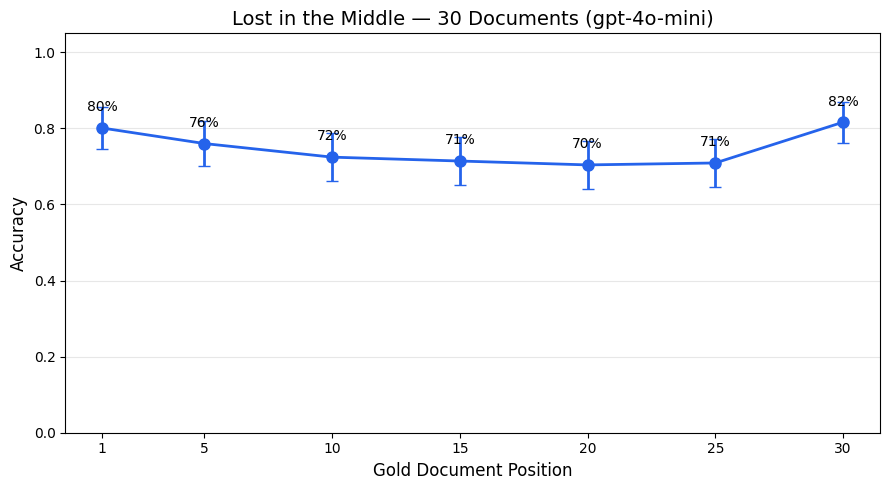


Accuracy by position:
  Position  1: 80% (157/196)
  Position  5: 76% (149/196)
  Position 10: 72% (142/196)
  Position 15: 71% (140/196)
  Position 20: 70% (138/196)
  Position 25: 71% (139/196)
  Position 30: 82% (160/196)


In [5]:
# If loading from saved results instead of re-running:
# df = pd.read_csv("../results/exp0_30doc_replication.csv")

acc_by_pos = df.groupby("gold_position")["correct"].agg(["mean", "count", "sum"])
acc_by_pos["se"] = (acc_by_pos["mean"] * (1 - acc_by_pos["mean"]) / acc_by_pos["count"]) ** 0.5

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    acc_by_pos.index, acc_by_pos["mean"],
    yerr=1.96 * acc_by_pos["se"],
    marker="o", linewidth=2, markersize=8, capsize=4, color="#2563eb"
)
ax.set_xlabel("Gold Document Position", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(f"Lost in the Middle — 30 Documents ({model})", fontsize=14)
ax.set_xticks(acc_by_pos.index)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

for pos, row in acc_by_pos.iterrows():
    ax.annotate(f"{row['mean']:.0%}", (pos, row["mean"]),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../results/exp0_30doc_u_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAccuracy by position:")
for pos, row in acc_by_pos.iterrows():
    print(f"  Position {pos:2d}: {row['mean']:.0%} ({int(row['sum'])}/{int(row['count'])})")

## Gate Check

In [6]:
edge_acc = acc_by_pos.loc[[1, 30], "mean"].mean()
middle_acc = acc_by_pos.loc[[10, 15, 20], "mean"].mean()
u_effect = edge_acc - middle_acc

print(f"Edge accuracy (pos 1, 30):     {edge_acc:.1%}")
print(f"Middle accuracy (pos 10,15,20): {middle_acc:.1%}")
print(f"U-curve effect size:            {u_effect:+.1%}")
print(f"Total questions:                {len(questions)}")
print(f"Total trials:                   {len(df)}")

if u_effect > 0.10:
    print("\n✓ Gate PASSED — clear U-shape detected. Proceed to Experiments 1–3.")
elif u_effect > 0.05:
    print("\n~ Marginal U-shape. Results may be noisy. Consider increasing N or using a weaker model.")
else:
    print("\n✗ Gate FAILED — no meaningful U-shape. Debug before continuing.")
    print("  Possible causes: model too strong, distractors too easy/hard, scoring issues.")

Edge accuracy (pos 1, 30):     80.9%
Middle accuracy (pos 10,15,20): 71.4%
U-curve effect size:            +9.4%
Total questions:                196
Total trials:                   1372

~ Marginal U-shape. Results may be noisy. Consider increasing N or using a weaker model.


## Spot Check: Sample Incorrect Responses

In [7]:
wrong = df[~df["correct"]].sample(min(15, (~df["correct"]).sum()), random_state=42)
for _, row in wrong.iterrows():
    print(f"Q: {row['question']}")
    print(f"  Expected: {row['expected']}")
    print(f"  Got:      {row['response']}")
    print(f"  Position: {row['gold_position']}")
    print()

Q: Who was the pastry chef for the 2024 Nobel Banquet?
  Expected: Frida Bäcke
  Got:      I don't know.
  Position: 10

Q: Who received the MusiCares Person of the Year award at the 66th Grammy Awards?
  Expected: Jon Bon Jovi
  Got:      I don't know.
  Position: 10

Q: Who was the pastry chef for the 2024 Nobel Banquet?
  Expected: Frida Bäcke
  Got:      I don't know.
  Position: 30

Q: What sentence was Ryan Wesley Routh given for the second assassination attempt on Trump?
  Expected: life without parole
  Got:      I don't know.
  Position: 25

Q: Which fantasy author born in 1975 celebrated a 50th birthday on December 19, 2025?
  Expected: Brandon Sanderson
  Got:      I don't know.
  Position: 20

Q: Who won Best New Artist at the 67th Annual Grammy Awards?
  Expected: Chappell Roan
  Got:      Victoria Monét
  Position: 1

Q: What was chosen as the Goal of the Tournament at Euro 2024?
  Expected: Lamine Yamal's semi-final goal
  Got:      Lamine Yamal's goal against France.
  

## Per-Question Analysis

Always correct (all 7 positions):  99 (51%)
Always wrong (all 7 positions):    16 (8%)
Position-sensitive (mixed):        81 (41%)
Total questions:                   196


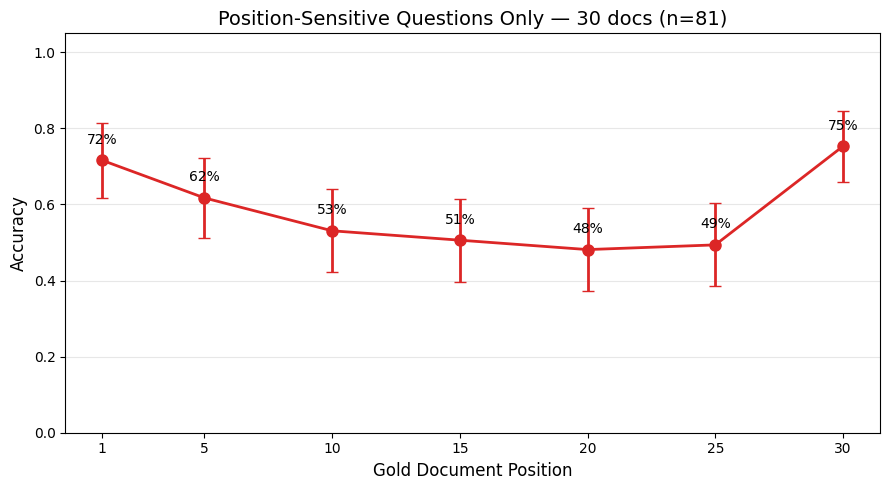


Mixed-only: edge=73%, middle=51%, effect=+23%


In [8]:
q_stats = df.groupby("question_id")["correct"].agg(["sum", "count"])
always_right = (q_stats["sum"] == q_stats["count"]).sum()
always_wrong = (q_stats["sum"] == 0).sum()
mixed = len(q_stats) - always_right - always_wrong

print(f"Always correct (all 7 positions):  {always_right} ({always_right/len(q_stats):.0%})")
print(f"Always wrong (all 7 positions):    {always_wrong} ({always_wrong/len(q_stats):.0%})")
print(f"Position-sensitive (mixed):        {mixed} ({mixed/len(q_stats):.0%})")
print(f"Total questions:                   {len(q_stats)}")

# Re-plot with only position-sensitive questions
if mixed > 20:
    mixed_ids = q_stats[(q_stats["sum"] > 0) & (q_stats["sum"] < q_stats["count"])].index
    df_mixed = df[df["question_id"].isin(mixed_ids)]

    acc_mixed = df_mixed.groupby("gold_position")["correct"].agg(["mean", "count", "sum"])
    acc_mixed["se"] = (acc_mixed["mean"] * (1 - acc_mixed["mean"]) / acc_mixed["count"]) ** 0.5

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(
        acc_mixed.index, acc_mixed["mean"],
        yerr=1.96 * acc_mixed["se"],
        marker="o", linewidth=2, markersize=8, capsize=4, color="#dc2626"
    )
    ax.set_xlabel("Gold Document Position", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title(f"Position-Sensitive Questions Only — 30 docs (n={mixed})", fontsize=14)
    ax.set_xticks(acc_mixed.index)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    for pos, row in acc_mixed.iterrows():
        ax.annotate(f"{row['mean']:.0%}", (pos, row["mean"]),
                    textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("../results/exp0_30doc_u_curve_mixed_only.png", dpi=150, bbox_inches="tight")
    plt.show()

    edge_m = acc_mixed.loc[[1, 30], "mean"].mean()
    mid_m = acc_mixed.loc[[10, 15, 20], "mean"].mean()
    print(f"\nMixed-only: edge={edge_m:.0%}, middle={mid_m:.0%}, effect={edge_m - mid_m:+.0%}")

## Clean Up Checkpoint

In [9]:
if os.path.exists(CHECKPOINT_PATH) and len(df) == len(questions) * len(POSITIONS):
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint removed — experiment complete.")
else:
    print(f"Keeping checkpoint ({len(df)}/{len(questions) * len(POSITIONS)} trials done)")

Checkpoint removed — experiment complete.


In [11]:
from scipy.stats import chi2, chi2_contingency
                                                                                                                                                                                                            
positions = sorted(df['gold_position'].unique())
pivot = df.pivot(index='question_id', columns='gold_position', values='correct').astype(int)                                                                                                              
k = len(positions)                                           

# 1. Cochran Q test (within-subjects omnibus)
col_sums = pivot.sum(axis=0)
row_sums = pivot.sum(axis=1)
T = row_sums.sum()
Q = ((k - 1) * (k * (col_sums**2).sum() - T**2)) / (k * T - (row_sums**2).sum())
p_cochran = 1 - chi2.cdf(Q, k - 1)
print(f"Cochran Q test: Q={Q:.3f}, df={k-1}, p={p_cochran:.6f}")

# 2. Chi-squared test of independence
contingency = pd.crosstab(df['gold_position'], df['correct'])
chi2_val, p_chi2, dof, _ = chi2_contingency(contingency)
print(f"Chi-squared:    χ²={chi2_val:.3f}, df={dof}, p={p_chi2:.6f}")

# 3. McNemar pairwise: each edge vs worst middle position
worst_mid = df[df['gold_position'].isin([10, 15, 20])].groupby('gold_position')['correct'].mean().idxmin()
print(f"\nMcNemar tests (vs worst middle = position {worst_mid}):")
for edge_pos in [1, 30]:
    b = ((pivot[edge_pos] == 1) & (pivot[worst_mid] == 0)).sum()
    c = ((pivot[edge_pos] == 0) & (pivot[worst_mid] == 1)).sum()
    stat = (abs(b - c) - 1)**2 / (b + c) if b + c > 0 else 0
    p = 1 - chi2.cdf(stat, 1) if b + c > 0 else 1.0
    print(f"  Pos {edge_pos:2d} vs {worst_mid}: edge_only={b}, mid_only={c}, χ²={stat:.3f}, p={p:.6f}")

# 4. Summary table
print(f"\nEdge accuracy (1, 30):      {acc_by_pos.loc[[1, 30], 'mean'].mean():.1%}")
print(f"Middle accuracy (10, 15, 20): {acc_by_pos.loc[[10, 15, 20], 'mean'].mean():.1%}")
print(f"U-effect:                     {acc_by_pos.loc[[1, 30], 'mean'].mean() - acc_by_pos.loc[[10, 15, 20], 'mean'].mean():+.1%}")

Cochran Q test: Q=27.279, df=6, p=0.000128
Chi-squared:    χ²=13.223, df=6, p=0.039623

McNemar tests (vs worst middle = position 20):
  Pos  1 vs 20: edge_only=29, mid_only=10, χ²=8.308, p=0.003948
  Pos 30 vs 20: edge_only=29, mid_only=7, χ²=12.250, p=0.000465

Edge accuracy (1, 30):      80.9%
Middle accuracy (10, 15, 20): 71.4%
U-effect:                     +9.4%
